<a href="https://colab.research.google.com/github/Elnazzareei/Predicting-Customer-Churn-with-Machine-Learning/blob/main/Predicting-Customer-Churn-with-Machine-Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
files=files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

print('-'*50)
print('Loading and exploring data')
print('-'*50)

# Load data
df=pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv', na_values=[' ', '?', ''])

# Explore data head
print(df.head())
print(df.info())

# Check missing values
print('\nMissing values: \n', df.isnull().sum())

# Check duplicate values
print('\nDuplicate values: \n', df.duplicated().sum())

--------------------------------------------------
Loading and exploring data
--------------------------------------------------
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4         

In [3]:
print ('-'*50)
print('Cleaning data')
print ('-'*50)

# Drop ID column
df.drop('customerID', axis=1, inplace=True)

# Convert 'TotalCharges' to numeric
df['TotalCharges']=pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check and remove missing values
print('\nMissing values after coversion:\n', df.isnull().sum())
df.dropna(inplace=True)
print('\nMissing values after droping missing values:\n', df.isnull().sum())

# Encod target ('Churn')
df['Churn']=df['Churn'].map({'Yes':1, 'No':0})

# Encod categorial column ('contract')
df['Contract_ordinal']=df['Contract'].map({'Month-to-month':0, 'One year':1, 'Two year':2})

# Drop original contract column to avoid duplication
df.drop('Contract', axis=1, inplace=True)

# One-hot encod categorial features exclude columns are already numeric or encoded
categorial_cols=df.select_dtypes(include=['object']).columns.to_list()
print('\ncategorial columns to encod: \n', categorial_cols)

# Apply one-hot encod
df=pd.get_dummies(df, columns=categorial_cols, drop_first=True)

# Verify final data
print('\nFinal dataset shape:\n', df.shape)
print('\nMissing values in final data:\n', df.isnull().sum().sum())
print('\nData types: \n', df.dtypes.value_counts())
print('\nTarget distribution (%churn):\n', df['Churn'].value_counts(normalize=True))
print('\nSample of cleaned data:\n', df.head())

--------------------------------------------------
Cleaning data
--------------------------------------------------

Missing values after coversion:
 gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

Missing values after droping missing values:
 gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0


--------------------------------------------------
Exploratory data analysis
--------------------------------------------------


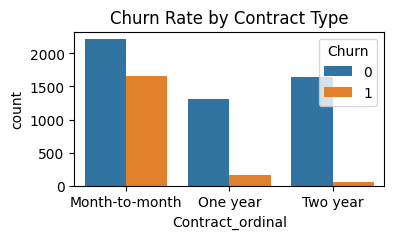

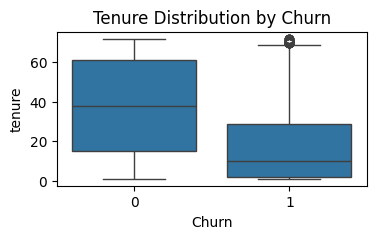

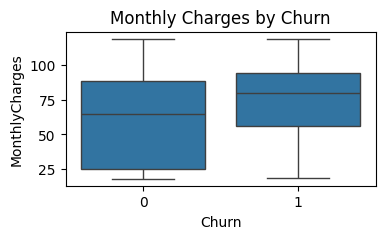

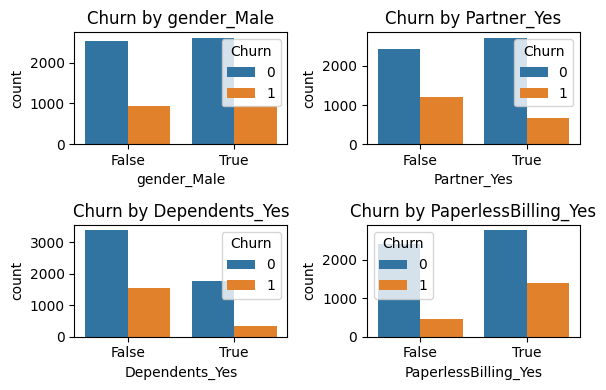


Contract_summary:
                 total_customers  churned_customers  churn_rate_%
Month_to_month             3875               1655          42.7
One year                   1472                166          11.3
Two year                   1685                 48           2.8


In [4]:
print('-' * 50)
print('Exploratory data analysis')
print('-' * 50)

# Compare churn vs non-churn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
import shap

# Churn rate by contract type
plt.figure(figsize=(4, 2))
sns.countplot(data=df, x='Contract_ordinal', hue='Churn')
plt.xticks(ticks=[0, 1, 2], labels=['Month-to-month', 'One year', 'Two year'])
plt.title('Churn Rate by Contract Type')
plt.show()

# Churn rate by tenure
plt.figure(figsize=(4, 2))
sns.boxplot(data=df, x='Churn', y='tenure')
plt.title('Tenure Distribution by Churn')
plt.show()

# Churn rate by MonthlyCharges
plt.figure(figsize=(4, 2))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges')
plt.title('Monthly Charges by Churn')
plt.show()

# Top categorial features
categorial_features=['gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PaperlessBilling_Yes']
fig, axes=plt.subplots(2, 2, figsize=(6, 4))
for i, feature in enumerate(categorial_features):
  row, col = divmod(i, 2)
  sns.countplot(data=df, x=feature, hue='Churn', ax=axes[row, col])
  axes[row, col].set_title(f'Churn by {feature}')
plt.tight_layout()
plt.show()

# Churn summary by contract group
contract_summary=df.groupby('Contract_ordinal')['Churn'].agg(
    total_customers='count',
    churned_customers='sum'
    )
contract_summary['churn_rate_%']=(contract_summary['churned_customers']/contract_summary['total_customers']*100).round(1)
contract_summary.index=['Month_to_month', 'One year', 'Two year']
print('\nContract_summary:\n', contract_summary)

--------------------------------------------------
Training models and evaluation
--------------------------------------------------
Training set size: 5625, Test set size: 1407
Churn rate in training: 0.266, in test : 0.266
Class imbalance ration (negative/positive): 2.76

Random Forest AUC (balanced): 0.8191

Logistic Regression AUC: 0.8354

XGBoost AUC: 0.8076


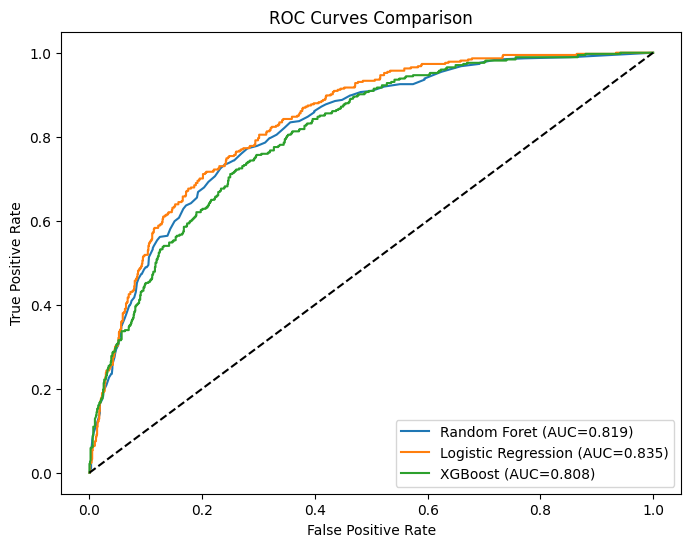

In [5]:
print('-' * 50)
print('Training models and evaluation')
print('-' * 50)

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report, roc_curve
from sklearn.preprocessing import StandardScaler
from matplotlib import use

# Prepare features and target
X=df.drop('Churn', axis=1)
y=df['Churn']

# Convert boolian data to int (for XGBoost & LR models)
X=X.astype({col: 'int64' for col in X.select_dtypes (include=['bool']).columns})

# Split data
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training set size: {X_train.shape[0]}, Test set size: {X_test.shape[0]}")
print(f"Churn rate in training: {y_train.mean():.3f}, in test : {y_test.mean():.3f}")

# Scale numeric columns
numeric_cols=['tenure', 'MonthlyCharges', 'TotalCharges']
scaler=StandardScaler()
X_train_scaled=X_train.copy()
X_test_scaled=X_test.copy()
X_train_scaled[numeric_cols]=scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols]=scaler.transform(X_test[numeric_cols])

# Calculate class weight for LR
scale_pos_weight=(len(y_train)-y_train.sum())/y_train.sum()
print(f"Class imbalance ration (negative/positive): {scale_pos_weight:.2f}")

# Train RF with class weight ('balanced')
rf_balanced=RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
    )
rf_balanced.fit(X_train_scaled, y_train)
rf_probs=rf_balanced.predict_proba(X_test_scaled)[:, 1]
rf_auc=roc_auc_score(y_test, rf_probs)
print(f"\nRandom Forest AUC (balanced): {rf_auc:.4f}")

# Logistic Regression with scale weight
lr=LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)
lr_probs=lr.predict_proba(X_test_scaled)[:, 1]
lr_auc=roc_auc_score(y_test, lr_probs)
print(f"\nLogistic Regression AUC: {lr_auc:.4f}")

# XGBoost with scale weight
xgb=XGBClassifier(
    n_estimators= 100,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
    )
xgb.fit(X_train, y_train)
xgb_probs=xgb.predict_proba(X_test)[:, 1]
xgb_auc=roc_auc_score(y_test, xgb_probs)
print(f"\nXGBoost AUC: {xgb_auc:.4f}")

# Compare ROC curves
plt.figure(figsize=(8, 6))
for name, probs, auc in [('Random Foret', rf_probs, rf_auc), ('Logistic Regression', lr_probs, lr_auc),
('XGBoost', xgb_probs, xgb_auc)]:
  fpr, tpr, _ =roc_curve(y_test, probs)
  plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend()
plt.show()

In [6]:
print('-'*50)
print('Failed experiment: Logistic Regression Coefficients')
print('-'*50)

# Get coefficients and intercept
coefs = lr.coef_[0]
intercept = lr.intercept_[0]

# Create DataFrame
coef_df=pd.DataFrame({
    'feature': X.columns,
    'coefficient': coefs,
    })
coef_df['abs_coef']=coef_df['coefficient'].abs()
coef_df_sorted=coef_df.sort_values(by='abs_coef', ascending=False)
print(f"Intercept: {intercept:.4f}")
print('\nTop 10 coefficients(positive=pushes to churn, negative=pushes away):')
print(coef_df_sorted[['feature', 'coefficient']].head(10))

--------------------------------------------------
Failed experiment: Logistic Regression Coefficients
--------------------------------------------------
Intercept: -0.5652

Top 10 coefficients(positive=pushes to churn, negative=pushes away):
                           feature  coefficient
1                           tenure    -1.258977
11     InternetService_Fiber optic     1.145644
4                 Contract_ordinal    -0.762779
3                     TotalCharges     0.617276
2                   MonthlyCharges    -0.502113
27  PaymentMethod_Electronic check     0.405889
22                 StreamingTV_Yes     0.389635
24             StreamingMovies_Yes     0.375585
8                 PhoneService_Yes    -0.375393
14              OnlineSecurity_Yes    -0.343845


--------------------------------------------------
Building Random Forest Feature Importance
--------------------------------------------------
Feature importances:
 1. TotalCharges                   0.1693
 2. tenure                         0.1598
 3. MonthlyCharges                 0.1551
 4. Contract_ordinal               0.1030
 5. InternetService_Fiber optic    0.0372
 6. PaymentMethod_Electronic check 0.0346
 7. OnlineSecurity_Yes             0.0296
 8. TechSupport_Yes                0.0254
 9. gender_Male                    0.0252
10. PaperlessBilling_Yes           0.0239
11. Partner_Yes                    0.0219
12. OnlineBackup_Yes               0.0216
13. Dependents_Yes                 0.0195
14. SeniorCitizen                  0.0181
15. MultipleLines_Yes              0.0177


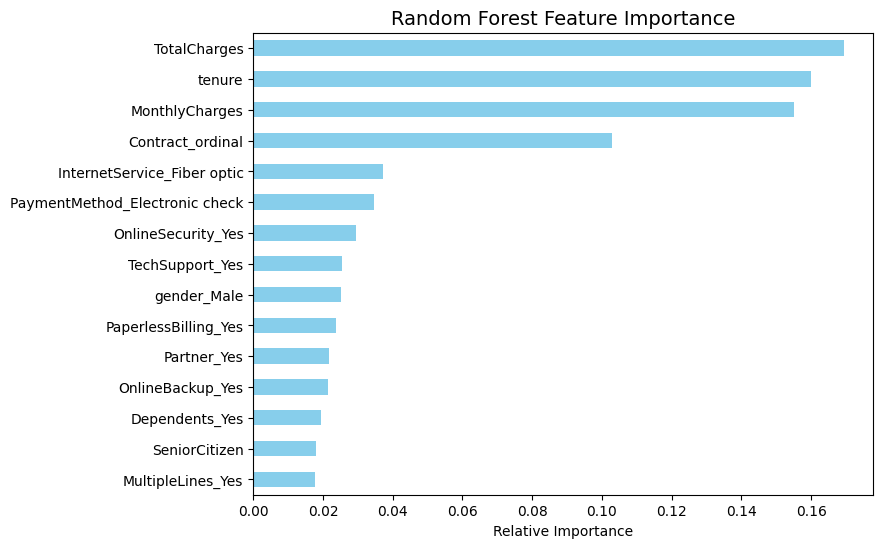

In [7]:
print('-'*50)
print('Building Random Forest Feature Importance')
print('-'*50)

# Extract feature importance from the trained model
importances=rf_balanced.feature_importances_
feature_names=X.columns
importance_series=pd.Series(importances, index=feature_names).sort_values(ascending=False)

# Plot top 15
print('Feature importances:')
for i, (feat, imp) in enumerate(importance_series.head(15).items(), 1):
    print(f"{i:2d}. {feat:30s} {imp:.4f}")
plt.figure(figsize=(8, 6))
importance_series.head(15).plot(kind='barh', color='skyblue')
plt.title('Random Forest Feature Importance', fontsize=14)
plt.xlabel('Relative Importance')
plt.gca().invert_yaxis()
plt.show()

In [8]:
print('-'*50)
print('Predicting probabilities using Random Forest')
print('-'*50)

# Predict probabilities on the test set using RF
rf_probs=rf_balanced.predict_proba(X_test_scaled)[:, 1]

# Create results datafarme
results_rf=X_test.copy()
results_rf['Churn_prob']=rf_probs
results_rf['actual_churn']=y_test.values

# Top 10 highest risk
top_risk_rf=results_rf.sort_values(by='Churn_prob', ascending=False).head(10)
print('\nTop 10 highest risk customers:')
print(top_risk_rf[['tenure', 'MonthlyCharges', 'Churn_prob', 'actual_churn', 'Contract_ordinal']])

--------------------------------------------------
Predicting probabilities using Random Forest
--------------------------------------------------

Top 10 highest risk customers:
      tenure  MonthlyCharges  Churn_prob  actual_churn  Contract_ordinal
809        1           69.55        1.00             1                 0
1739       1           69.90        1.00             1                 0
2927       1           69.90        1.00             0                 0
4484       1           70.35        0.99             0                 0
684        1           71.10        0.99             0                 0
5393       1           70.60        0.99             1                 0
1731       1           69.60        0.99             1                 0
6633       1           74.50        0.98             1                 0
1144       1           35.55        0.98             1                 0
2464       1           77.15        0.97             1                 0
